In [1]:
import numpy as np # linear algebra....
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)....
from matplotlib import pyplot as plt #Visualization of the data....
%matplotlib inline
# seaborn for some special plots
import seaborn as sns
#datetime for datetime operations.
from datetime import date
#ignore the warnings  
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",None)
# for silhouette scores calculation
from sklearn.metrics import silhouette_score, silhouette_samples
#libraries for plotting
import matplotlib.cm as cm
import plotly.express as px

In [2]:
food_orders = pd.read_csv("food.csv")

In [3]:
food_orders.head()

,Order ID,Customer ID,Restaurant ID,Order Date and Time,Delivery Date and Time,Order Value,Delivery Fee,Payment Method,Discounts and Offers,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
0,1,C8270,R2924,01-02-2024 01:11,01-02-2024 02:39,1914,0,Credit Card,5% on App,150,47,0
1,2,C1860,R2054,02-02-2024 22:11,02-02-2024 22:46,986,40,Digital Wallet,10%,198,23,0
2,3,C6390,R2870,31-01-2024 05:54,31-01-2024 06:52,937,30,Cash on Delivery,15% New User,195,45,0
3,4,C6191,R2642,16-01-2024 22:52,16-01-2024 23:38,1463,50,Cash on Delivery,NaN,146,27,0
4,5,C6734,R2799,29-01-2024 01:19,29-01-2024 02:48,1992,30,Cash on Delivery,50 off Promo,130,50,0


In [4]:
food_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   Order ID                1000 non-null   int64 
 1   Customer ID             1000 non-null   object
 2   Restaurant ID           1000 non-null   object
 3   Order Date and Time     1000 non-null   object
 4   Delivery Date and Time  1000 non-null   object
 5   Order Value             1000 non-null   int64 
 6   Delivery Fee            1000 non-null   int64 
 7   Payment Method          1000 non-null   object
 8   Discounts and Offers    815 non-null    object
 9   Commission Fee          1000 non-null   int64 
 10  Payment Processing Fee  1000 non-null   int64 
 11  Refunds/Chargebacks     1000 non-null   int64 
dtypes: int64(6), object(6)
memory usage: 93.9+ KB


In [5]:
food_orders.describe()

,Order ID,Order Value,Delivery Fee,Commission Fee,Payment Processing Fee,Refunds/Chargebacks
count,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,1053.969000,28.620000,126.99000,29.832000,28.300000
std,288.819436,530.975339,16.958278,43.06405,11.627165,49.614228
min,1.000000,104.000000,0.000000,50.00000,10.000000,0.000000
25%,250.750000,597.750000,20.000000,90.00000,20.000000,0.000000
50%,500.500000,1038.500000,30.000000,127.00000,30.000000,0.000000
75%,750.250000,1494.000000,40.000000,164.00000,40.000000,50.000000
max,1000.000000,1995.000000,50.000000,200.00000,50.000000,150.000000


In [6]:
for column in food_orders.columns:
    print(food_orders[column].nunique())

1000
947
621
994
992
769
5
3
4
151
41
4


In [7]:
food_orders['Discount (%)'] = food_orders['Discounts and Offers'].str.extract(r'(\d+)')  # Extract numbers
food_orders['Discount (%)'] = pd.to_numeric(food_orders['Discount (%)'], errors='coerce')  # Convert to numeric


In [8]:
food_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order ID                1000 non-null   int64  
 1   Customer ID             1000 non-null   object 
 2   Restaurant ID           1000 non-null   object 
 3   Order Date and Time     1000 non-null   object 
 4   Delivery Date and Time  1000 non-null   object 
 5   Order Value             1000 non-null   int64  
 6   Delivery Fee            1000 non-null   int64  
 7   Payment Method          1000 non-null   object 
 8   Discounts and Offers    815 non-null    object 
 9   Commission Fee          1000 non-null   int64  
 10  Payment Processing Fee  1000 non-null   int64  
 11  Refunds/Chargebacks     1000 non-null   int64  
 12  Discount (%)            815 non-null    float64
dtypes: float64(1), int64(6), object(6)
memory usage: 101.7+ KB


In [9]:
food_orders['Discount (%)'].head()

0     5.0
1    10.0
2    15.0
3     NaN
4    50.0
Name: Discount (%), dtype: float64

In [10]:
food_orders['Discount (%)'].fillna(0, inplace=True)

# Calculate the actual discount amount
food_orders['Discount Amount'] = (food_orders['Discount (%)'] / 100) * food_orders['Order Value']

# Calculate the final cost after applying discount
food_orders['Final Cost'] = food_orders['Order Value'] - food_orders['Discount Amount']


In [11]:
food_orders['Final Cost'].head()

0    1818.30
1     887.40
2     796.45
3    1463.00
4     996.00
Name: Final Cost, dtype: float64

In [14]:
# calculate total costs and revenue per order
food_orders['Total Costs'] = food_orders['Delivery Fee'] + food_orders['Payment Processing Fee'] + food_orders['Discount Amount'] + food_orders['Refunds/Chargebacks'] 
food_orders['Revenue'] = food_orders['Commission Fee']
food_orders['Profit'] = food_orders['Revenue'] - food_orders['Total Costs']

# aggregate data to get overall metrics
total_orders = food_orders.shape[0]
total_revenue = food_orders['Revenue'].sum()
total_costs = food_orders['Total Costs'].sum()
total_profit = food_orders['Profit'].sum()

overall_metrics = {
    "Total Orders": total_orders,
    "Total Revenue": total_revenue,
    "Total Costs": total_costs,
    "Total Profit": total_profit
}

print(overall_metrics)

{'Total Orders': 1000, 'Total Revenue': 126990, 'Total Costs': 261009.84999999998, 'Total Profit': -134019.85}


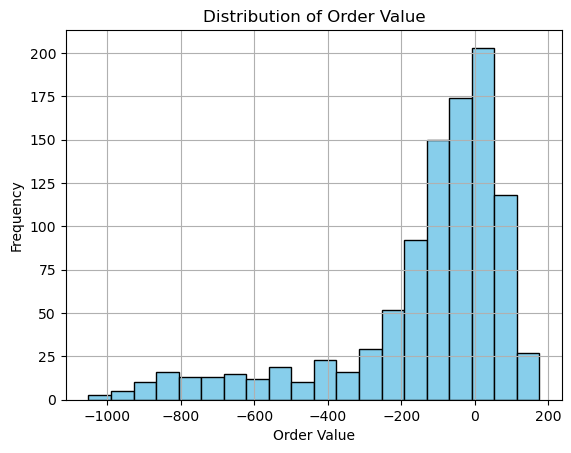

In [16]:
plt.hist(food_orders['Profit'], bins=20, color='skyblue', edgecolor='black')
plt.title('Distribution of Order Value')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

<Axes: xlabel='Payment Method', ylabel='Profit'>

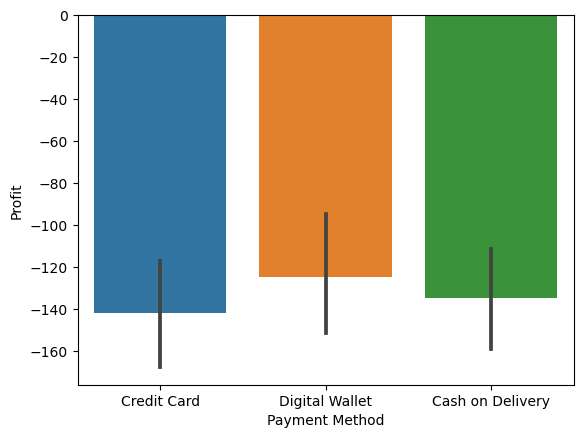

In [18]:
sns.barplot(data = food_orders, x = 'Payment Method', y = 'Profit' )

In [20]:
profitable_orders = food_orders[food_orders['Profit'] > 0]

In [21]:
# calculate the average commission percentage for profitable orders
profitable_orders['Commission Percentage'] = (profitable_orders['Commission Fee'] / profitable_orders['Order Value']) * 100

# calculate the average discount percentage for profitable orders
profitable_orders['Effective Discount Percentage'] = (profitable_orders['Discount Amount'] / profitable_orders['Order Value']) * 100

# calculate the new averages
new_avg_commission_percentage = profitable_orders['Commission Percentage'].mean()
new_avg_discount_percentage = profitable_orders['Effective Discount Percentage'].mean()

print(new_avg_commission_percentage, new_avg_discount_percentage)

31.59734746146822 5.7975460122699385


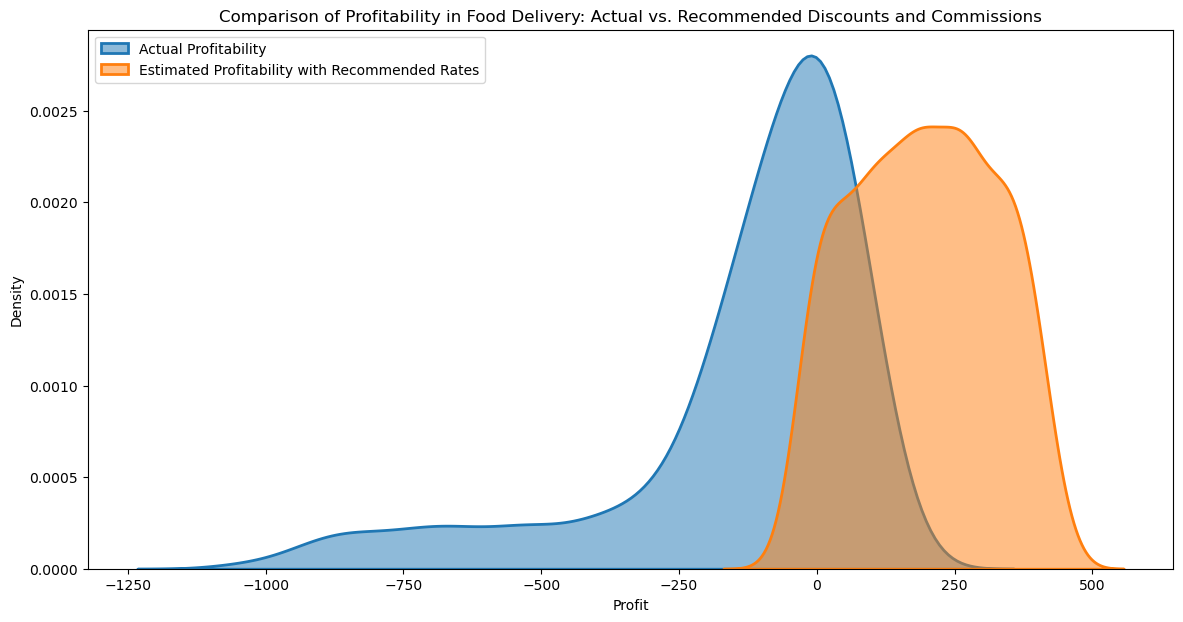

In [22]:
# simulate profitability with recommended discounts and commissions
recommended_commission_percentage = 30.0  # 30%
recommended_discount_percentage = 6.0    # 6%

# calculate the simulated commission fee and discount amount using recommended percentages
food_orders['Simulated Commission Fee'] = food_orders['Order Value'] * (recommended_commission_percentage / 100)
food_orders['Simulated Discount Amount'] = food_orders['Order Value'] * (recommended_discount_percentage / 100)

# recalculate total costs and profit with simulated values
food_orders['Simulated Total Costs'] = (food_orders['Delivery Fee'] +
                                        food_orders['Payment Processing Fee'] +
                                        food_orders['Simulated Discount Amount'])

food_orders['Simulated Profit'] = (food_orders['Simulated Commission Fee'] -
                                   food_orders['Simulated Total Costs'])

# visualizing the comparison
import seaborn as sns

plt.figure(figsize=(14, 7))

# actual profitability
sns.kdeplot(food_orders['Profit'], label='Actual Profitability', fill=True, alpha=0.5, linewidth=2)

# simulated profitability
sns.kdeplot(food_orders['Simulated Profit'], label='Estimated Profitability with Recommended Rates', fill=True, alpha=0.5, linewidth=2)

plt.title('Comparison of Profitability in Food Delivery: Actual vs. Recommended Discounts and Commissions')
plt.xlabel('Profit')
plt.ylabel('Density')
plt.legend(loc='upper left')
plt.show()